In [35]:
import pandas as pd
def datasetexploration(dataset):
  # Load dataset
  df = pd.read_csv(dataset)   # change filename if needed

  # Basic info
  print("Shape of dataset:", df.shape)  # rows, columns
  print("\nColumn names:\n", df.columns.tolist())

  # Data types + missing values
  print("\nInfo:")
  print(df.info())

  # Check first few rows
  print("\nHead:")
  print(df.head())

  # Unique values for categorical columns
  for col in df.select_dtypes(include=['object']).columns:
      print(f"\nUnique values in {col}:")
      print(df[col].unique()[:])  # show first 20 unique

  # Statistical summary
  print("\nDescribe (numerical):")
  print(df.describe())

  print("\nDescribe (categorical):")
  print(df.describe(include=['object']))


In [36]:
datasetexploration("crop_yield.csv")


Shape of dataset: (19689, 10)

Column names:
 ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB
None

Head:
           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1

# **Random split**
### **Preprocessing**

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load your dataset
df = pd.read_csv('crop_yield.csv')

# ---------------------------
# Step 1: Clean categorical columns
# ---------------------------
df['Crop'] = df['Crop'].str.strip()
df['Season'] = df['Season'].str.strip()
df['State'] = df['State'].str.strip()

# ---------------------------
# Step 2: Handle outliers (optional)
# Here, using log transform for skewed numerical columns
# Add small constant to avoid log(0)
numeric_cols = ['Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']
df[numeric_cols] = df[numeric_cols].apply(lambda x: np.log1p(x))

# ---------------------------
# Step 3: Encode categorical columns
# ---------------------------
label_encoders = {}
for col in ['Crop', 'State', 'Season']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store for inverse transform later

# ---------------------------
# Step 4: Feature scaling (StandardScaler)
# ---------------------------
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# ---------------------------
# Step 5: Split features and target
# ---------------------------
X = df.drop('Yield', axis=1)
y = df['Yield']

# Now X and y are ready for ML models
print("Preprocessing complete. Features and target ready for modeling.")
print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Preprocessing complete. Features and target ready for modeling.
Feature shape: (19689, 9)
Target shape: (19689,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape, y_train.shape)
print("Testing shape:", X_test.shape, y_test.shape)


Training shape: (15751, 9) (15751,)
Testing shape: (3938, 9) (3938,)


### Models

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Metrics:
MAE: 0.17807436978408764
RMSE: 0.30168829395179947
R2 Score: 0.9068099867131558


In [10]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2 Score:", r2_score(y_test, y_pred_dt))


Decision Tree Metrics:
MAE: 0.07303214887961769
RMSE: 0.13331644927106368
R2 Score: 0.9818021562453502


In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest Metrics:
MAE: 0.05121644374646257
RMSE: 0.08791369479627523
R2 Score: 0.992086556225883


In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))


XGBoost Results:
R2 Score: 0.990909413044869
RMSE: 0.0942257786401818
MAE: 0.05157386096124678


/tmp/ipython-input-1310082058.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


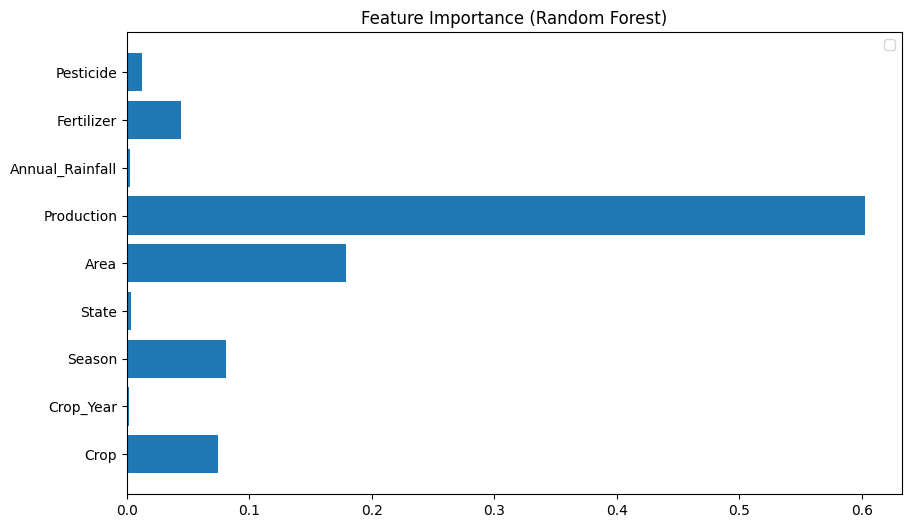

In [14]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.legend()
plt.show()


# **Time based Split**


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib
from prophet import Prophet


In [4]:
df = pd.read_csv('crop_yield.csv')

df['Crop'] = df['Crop'].str.strip()
df['Season'] = df['Season'].str.strip()
df['State'] = df['State'].str.strip()

numeric_cols = ['Area','Production','Annual_Rainfall','Fertilizer','Pesticide']
# Using log1p to reduce skewness
df[numeric_cols] = df[numeric_cols].apply(lambda x: np.log1p(x))

label_encoders = {}
for col in ['Crop','State','Season']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # store for later inverse transform

scaler_X = StandardScaler()
df[numeric_cols] = scaler_X.fit_transform(df[numeric_cols])

# Optional: scale target for neural networks (not needed for tree models)
# scaler_y = StandardScaler()
# df['Yield_scaled'] = scaler_y.fit_transform(df['Yield'].values.reshape(-1,1))

X = df.drop('Yield', axis=1)
y = df['Yield']


In [5]:
# ------------------------
# Time-based train-test split
# Train on older years, test on recent years to avoid leakage
# ------------------------
train = df[df['Crop_Year'] <= 2016]
test = df[df['Crop_Year'] > 2016]

X_train = train.drop('Yield', axis=1)
y_train = train['Yield']
X_test = test.drop('Yield', axis=1)
y_test = test['Yield']

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (16440, 9) (16440,)
Testing set shape: (3249, 9) (3249,)


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Linear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Metrics:
MAE: 326.8469588976851
RMSE: 734.1471906162574
R2 Score: 0.244633453772387



Random Forest Results:
R2 Score: 0.9514443847639836
RMSE: 186.13326628421117
MAE: 13.017764358019773


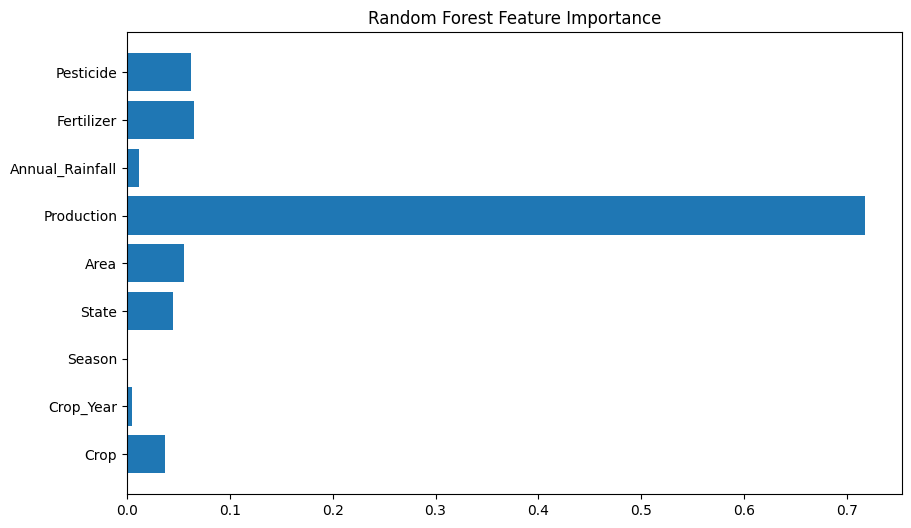

['scaler_X.pkl']

In [7]:
# ------------------------
# Random Forest Model
# ------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Results:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

# Feature importance plot
importances = rf.feature_importances_
plt.figure(figsize=(10,6))
plt.barh(X_train.columns, importances)
plt.title("Random Forest Feature Importance")
plt.show()

# Save model and encoders/scaler
joblib.dump(rf, 'rf_yield_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(scaler_X, 'scaler_X.pkl')



In [8]:

# ------------------------
# STEP 9: XGBoost Model
# ------------------------
xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results:")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))

# Save model
joblib.dump(xgb, 'xgb_yield_model.pkl')


XGBoost Results:
R2 Score: 0.6442838429460657
RMSE: 503.7975645332158
MAE: 23.957650034142198


['xgb_yield_model.pkl']

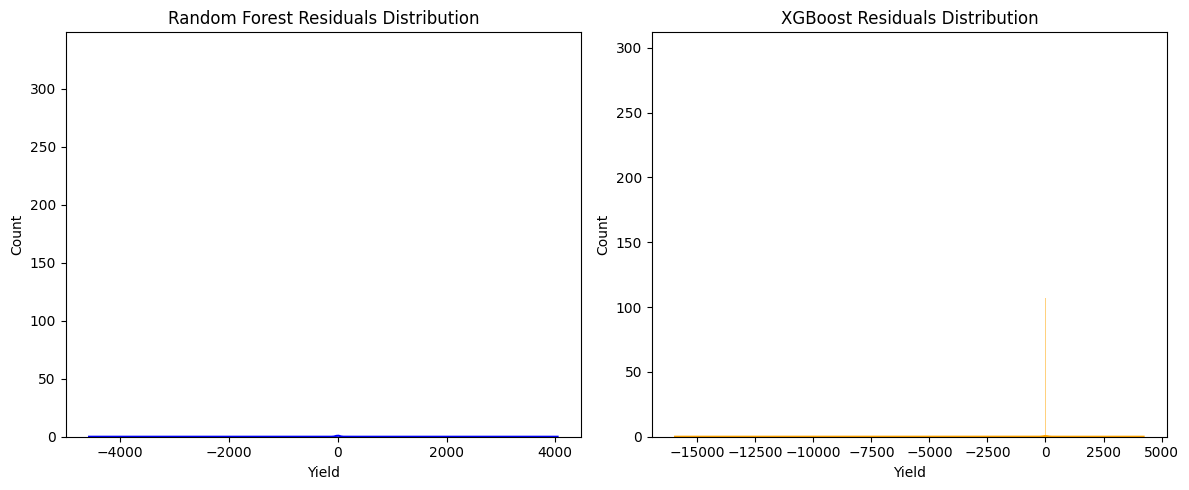

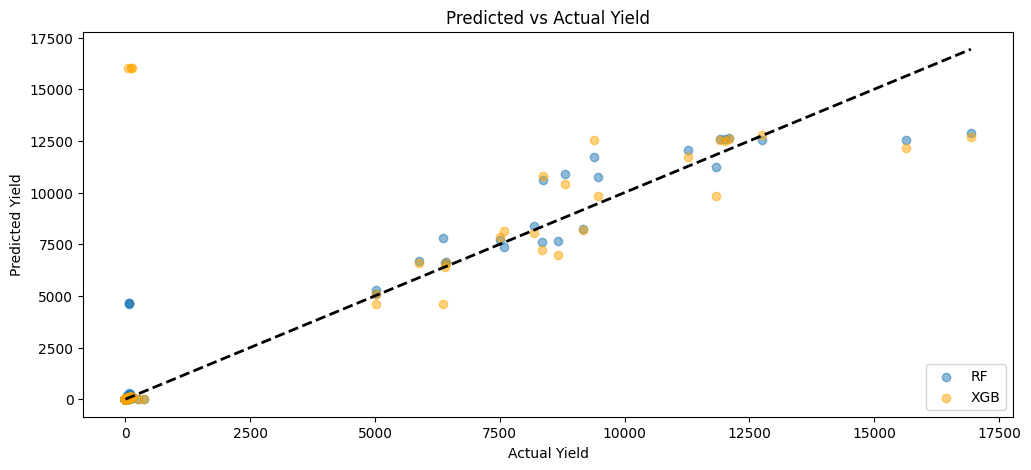

In [9]:
# ------------------------
# STEP 8: Residual Analysis
# ------------------------
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(residuals_rf, kde=True, color='blue')
plt.title("Random Forest Residuals Distribution")

plt.subplot(1,2,2)
sns.histplot(residuals_xgb, kde=True, color='orange')
plt.title("XGBoost Residuals Distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='RF')
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label='XGB', color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs Actual Yield")
plt.legend()
plt.show()

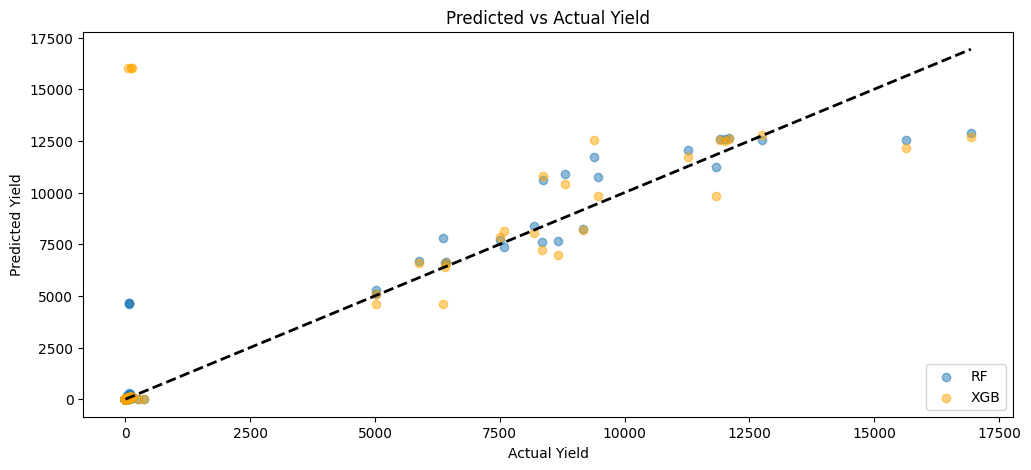

In [13]:
plt.figure(figsize=(12,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5, label='RF')
plt.scatter(y_test, y_pred_xgb, alpha=0.5, label='XGB', color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Predicted vs Actual Yield")
plt.legend()
plt.show()

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzzu0mdm3/xnac544q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzzu0mdm3/tst4e7g_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=33870', 'data', 'file=/tmp/tmpzzu0mdm3/xnac544q.json', 'init=/tmp/tmpzzu0mdm3/tst4e7g_.json', 'output', 'file=/tmp/tmpzzu0mdm3/prophet_model35jhi__2/prophet_model-20250930213128.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
21:31:28 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
21:31:28 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
/usr/local/lib/python3.12/dist-packages

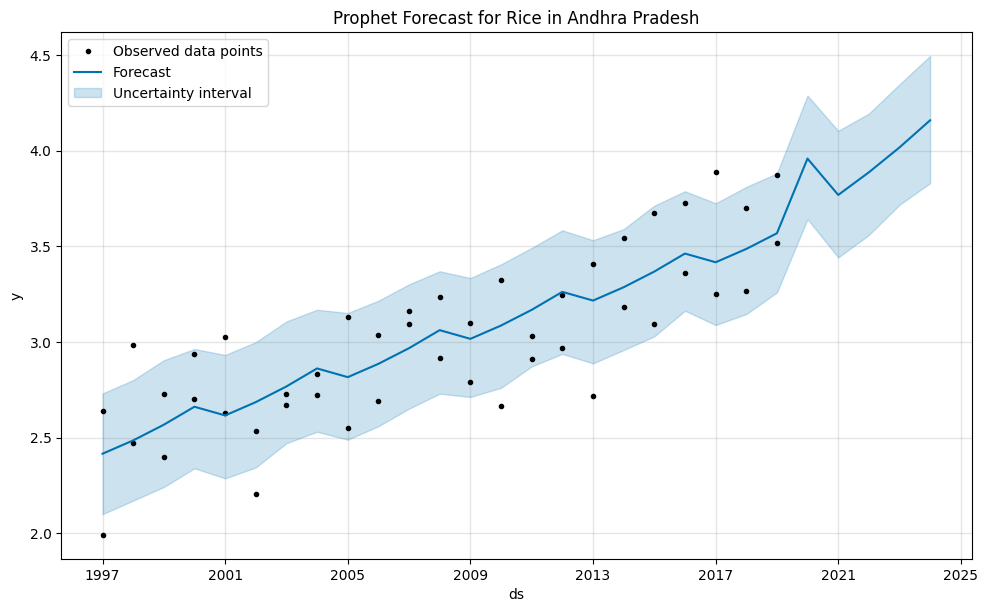

In [10]:
# ------------------------
# STEP 10: Prophet Forecasting (per Crop-State)
# ------------------------
# Example: Forecasting 'Rice' in 'Andhra Pradesh' for next 5 years

# Use original string values (before label encoding) for clarity
df_prophet = df.copy()
le_crop = label_encoders['Crop']
le_state = label_encoders['State']

# Filter crop and state
crop_name = 'Rice'
state_name = 'Andhra Pradesh'
df_prophet = df_prophet[(df_prophet['Crop'] == le_crop.transform([crop_name])[0]) &
                        (df_prophet['State'] == le_state.transform([state_name])[0])]

# Prepare for Prophet
df_ts = df_prophet[['Crop_Year','Yield']].rename(columns={'Crop_Year':'ds','Yield':'y'})
df_ts['ds'] = pd.to_datetime(df_ts['ds'], format='%Y')

# Fit Prophet model
m = Prophet(yearly_seasonality=True)
m.fit(df_ts)

# Forecast next 5 years
future = m.make_future_dataframe(periods=5, freq='Y')
forecast = m.predict(future)

# Plot forecast
fig1 = m.plot(forecast)
plt.title(f"Prophet Forecast for {crop_name} in {state_name}")
plt.legend()
plt.show()
